In [40]:
# Helper functions
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import app

def convert_datetime_to_date_with_resampling(df: pd.DataFrame):
    new_df = df.copy()
    new_df["date"] = pd.to_datetime(new_df["datetime"]).dt.date
    new_df["date"] = pd.to_datetime(new_df["date"])
    new_df.groupby("date").mean(numeric_only=True)
    return new_df

def merge_on_date(df1: pd.DataFrame, df2: pd.DataFrame):
    # Copy
    newdf1 = df1.copy()
    newdf2 = df2.copy()
    newdf1["date"] = pd.to_datetime(newdf1["date"]).dt.normalize()
    newdf2["date"] = pd.to_datetime(newdf2["date"]).dt.normalize()
    newdf1 = newdf1.merge(newdf2, on="date", how="left")
    newdf1 = newdf1.dropna()
    newdf1.groupby("date").mean(numeric_only=True)
    newdf1 = newdf1.reset_index()
    return newdf1

def merge_and_average_by_date(df: pd.DataFrame) -> pd.DataFrame:
    newdf = df[['date', 'escherichia coli count', 'value']].copy()
    newdf['date'] = pd.to_datetime(newdf['date']).dt.normalize()
    merged_daily = newdf.groupby('date', as_index=False).mean(numeric_only=True)
    return merged_daily

def plot_values_vs_date(merged: pd.DataFrame, x: str, y1: str, y2: str, xlabel: str, y1label: str, y2label: str):
    fig, ax1 = plt.subplots(figsize=(10,5))
    print(merged.columns)
    ax1.plot(merged[x], merged[y1], marker='o', label=y1label)
    ax1.set_ylabel(y1label)
    ax2 = ax1.twinx()
    ax2.plot(merged[x], merged[y2], marker='o', color='orange', label=y2label)
    ax2.set_ylabel(y2label)
    plt.title("")
    ax1.set_xlabel(xlabel)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.show()

In [41]:
# Get FDOM determinand info
determinands = app.get_determinands_as_pandas(display=False)
# print(determinands.iloc[12]["datasets"])
# yields for FDOM [{'code': 'ea_wq_sonde', 'id': 'fdom'}]
fdom_dataset_id = "ea_wq_sonde"
fdom_determinand_id = "fdom"
wolvercote_sonde_site_id = "E01612A"

# Get data on dissolved dissolved organic solids
df_fdom_sonde_wolvercote = app.get_timeseries_for_dataset_site_determinand_as_pandas(wolvercote_sonde_site_id, fdom_dataset_id, fdom_determinand_id, display=False)
# resample
df_organic_sonde_wolvercote_resampled = convert_datetime_to_date_with_resampling(df_fdom_sonde_wolvercote)

In [42]:
# Get wolvercote ecoli data
ecoli_timeseries_dfs = app.get_ecoli_datasets()
bathing_water_dataset_id = "ea_bathing_water"
wolvercote_ecoli_site_id = "11946"
wolvercote_ecoli_timeseries = ecoli_timeseries_dfs[(wolvercote_ecoli_site_id, bathing_water_dataset_id)]
# resample
wolvercote_ecoli_resampled = convert_datetime_to_date_with_resampling(wolvercote_ecoli_timeseries)

Index(['date', 'escherichia coli count', 'value'], dtype='object')


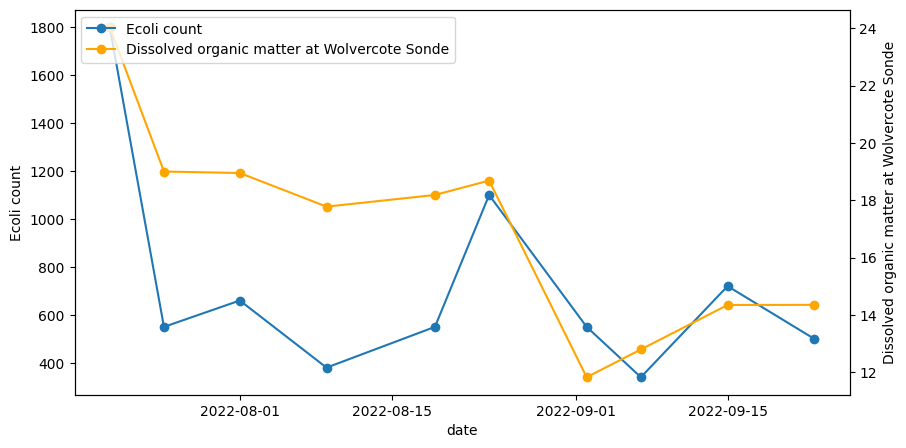

In [43]:
# merge and plot
merged = merge_and_average_by_date(merge_on_date(wolvercote_ecoli_resampled, df_organic_sonde_wolvercote_resampled))
plot_values_vs_date(merged, "date", 'escherichia coli count', "value", "date", "Ecoli count", "Dissolved organic matter at Wolvercote Sonde")

85.98704382623741 -746.1957497067161 0.7225199468253268


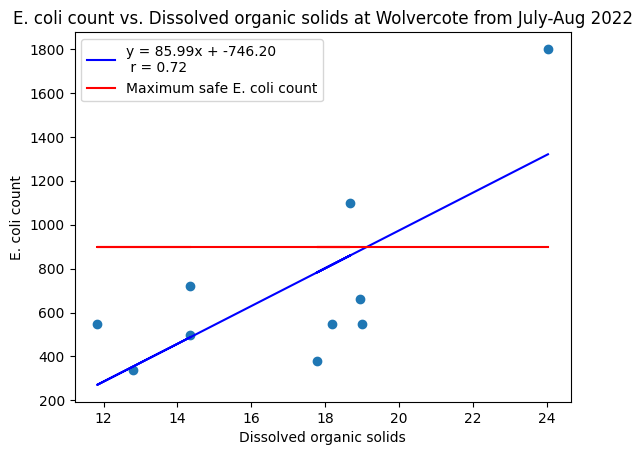

In [44]:
# Correlation analysis
plt.scatter(merged["value"], merged["escherichia coli count"])
m, b = np.polyfit(merged["value"], merged["escherichia coli count"], 1)
r = np.corrcoef(merged["value"], merged["escherichia coli count"])[0, 1]
print(m, b, r)
plt.plot(merged["value"], m*merged["value"] + b, color="blue", label=f"y = {m:.2f}x + {b:.2f}\n r = {r:.2f}")
plt.xlabel("Dissolved organic solids")
plt.ylabel("E. coli count")
plt.title("E. coli count vs. Dissolved organic solids at Wolvercote from July-Aug 2022")
plt.plot(merged["value"], np.ones(len(merged["value"]))*900, color="red", label="Maximum safe E. coli count")
plt.legend()
plt.show()